<a href="https://colab.research.google.com/github/Ennydaniel/Ptzza-Place-Sales-Analysis/blob/main/Tuberculosis_Treatment_Default_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder, OrdinalEncoder

from sklearn.pipeline import Pipeline

from imblearn.pipeline import Pipeline as ImbPipeline

from imblearn.over_sampling import SMOTE

from sklearn.compose import ColumnTransformer

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV, RandomizedSearchCV

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier, VotingClassifier

from sklearn.svm import SVC

from sklearn.inspection import permutation_importance

from xgboost import XGBClassifier

from lightgbm import LGBMClassifier

from sklearn.metrics import f1_score, recall_score, make_scorer, auc, roc_curve, classification_report, ConfusionMatrixDisplay, precision_recall_curve, average_precision_score

import warnings

warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

#DATA PREPARATION FOR ANALYSIS

####DATA CLEANING

In [ ]:
# Opening The CSV File

df = pd.read_csv(r'/content/Untitled spreadsheet - CLEANED_DATA (1).csv')

df.head(20)

,S/N,Treatment_Default,Age,Occupation,Sex,Residence,HIV_Status,Previous_TB_History,Type_Of_TB,Initial_Weight,Method_Of_Diagnosis,Treatment_Regimen,DOTS_Attendance,Date_Treatment_Started
0,1,No,59,Farmer,Female,Semi-Urban,Negative,New,Pulmonary TB,80,Gene-Xpert,First-Line R-6,Yes,6/1/2020
1,2,No,20,Student,Female,Semi-Urban,Negative,New,Pulmonary TB,45,X-Ray,First-Line R-6,Yes,6/1/2020
2,3,No,56,Trader,Male,Rural,Negative,New,Pulmonary TB,45,Gene-Xpert,First-Line R-6,Yes,8/1/2020
3,4,Yes,17,Student,Female,Semi-Urban,Positive,New,Pulmonary TB,35,X-Ray,First-Line R-6,Yes,8/1/2020
4,5,No,45,Civil servant,Female,Rural,Negative,New,Pulmonary TB,45,Gene-Xpert,First-Line R-6,Yes,13/1/2020
5,6,Yes,46,Farmer,Male,Rural,Negative,New,Pulmonary TB,80,X-Ray,First-Line R-6,Yes,14/1/2020
6,7,No,45,Civil servant,Female,Semi-Urban,Negative,New,Pulmonary TB,70,X-Ray,First-Line R-6,Yes,3/2/2020
7,8,No,64,Trader,Male,Rural,Negative,New,Pulmonary TB,75,X-Ray,First-Line R-6,Yes,3/2/2020
8,9,Yes,80,Unemployed,Male,Rural,Negative,New,Pulmonary TB,50,X-Ray,First-Line R-6,Yes,3/2/2020
9,10,Yes,30,Civil servant,Female,Semi-Urban,Positive,New,Pulmonary TB,80,X-Ray,First-Line R-6,Yes,22/1/2020


In [ ]:
# Get Dataset information

df.info(max_cols = None)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 868 entries, 0 to 867
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   S/N                     868 non-null    int64 
 1   Treatment_Default       868 non-null    object
 2   Age                     868 non-null    int64 
 3   Occupation              868 non-null    object
 4   Sex                     868 non-null    object
 5   Residence               868 non-null    object
 6   HIV_Status              868 non-null    object
 7   Previous_TB_History     868 non-null    object
 8   Type_Of_TB              868 non-null    object
 9   Initial_Weight          868 non-null    int64 
 10  Method_Of_Diagnosis     868 non-null    object
 11  Treatment_Regimen       868 non-null    object
 12  DOTS_Attendance         868 non-null    object
 13  Date_Treatment_Started  868 non-null    object
dtypes: int64(3), object(11)
memory usage: 95.1+ KB


In [ ]:
# Get Data shape

shape = df.shape

print(f'The Dataset has {shape[0]} Rows and {shape[1]} Columns')

The Dataset has 868 Rows and 14 Columns


In [ ]:
# Check for Empty cells

df.isna().sum()

,0
S/N,0
Treatment_Default,0
Age,0
Occupation,0
Sex,0
Residence,0
HIV_Status,0
Previous_TB_History,0
Type_Of_TB,0
Initial_Weight,0


In [ ]:
# Check for Null Values

df.isnull().sum()

,0
S/N,0
Treatment_Default,0
Age,0
Occupation,0
Sex,0
Residence,0
HIV_Status,0
Previous_TB_History,0
Type_Of_TB,0
Initial_Weight,0


In [ ]:
# Check for Duplicates

df.duplicated().sum()

np.int64(0)

In [ ]:
# Get the Value Count of each Column

df.nunique().sort_values()


,0
Treatment_Default,2
Sex,2
Residence,2
Type_Of_TB,2
Treatment_Regimen,2
DOTS_Attendance,2
Previous_TB_History,3
HIV_Status,3
Method_Of_Diagnosis,3
Occupation,5


#DATA CATEGORIZATION

#####REDUNDANCY CHECK

In [ ]:
# Get redundant columns

redundant_cols = []

for col in df.columns.tolist() :
     if df[col].value_counts().nunique() == 1 :
        redundant_cols.append(col)

redundant_cols

['S/N']

In [ ]:
# Remove redundancy

df.drop(columns = redundant_cols, inplace = True)

len(df.columns)


13

#####COLUMN CHECK

In [ ]:
# Check for Numerical Columns

numerical_cols = df.select_dtypes(include = 'number').columns.tolist()

print(str( len(numerical_cols) ) + ' Numerical Columns \n \n' + str(numerical_cols) )

2 Numerical Columns 
 
['Age', 'Initial_Weight']


In [ ]:
# Check for Categorical Columns

nominal_cols = df.select_dtypes( include = ['object'] ).columns.tolist()

print(str( len(nominal_cols) ) + ' Nominal Categorical Columns \n \n' + str(nominal_cols) )

11 Nominal Categorical Columns 
 
['Treatment_Default', 'Occupation', 'Sex', 'Residence', 'HIV_Status', 'Previous_TB_History', 'Type_Of_TB', 'Method_Of_Diagnosis', 'Treatment_Regimen', 'DOTS_Attendance', 'Date_Treatment_Started']


In [ ]:
# Get Ordinal categorical columns

ordinal_cols = df.select_dtypes(  include = ['object'] ) .columns.tolist()
print(str( len(ordinal_cols) ) + ' Ordinal Categorical Columns \n \n' + str(ordinal_cols) )

11 Ordinal Categorical Columns 
 
['Treatment_Default', 'Occupation', 'Sex', 'Residence', 'HIV_Status', 'Previous_TB_History', 'Type_Of_TB', 'Method_Of_Diagnosis', 'Treatment_Regimen', 'DOTS_Attendance', 'Date_Treatment_Started']


In [ ]:
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    print(f"\n{col}")
    print(df[col].value_counts())



Treatment_Default
Treatment_Default
No     668
Yes    200
Name: count, dtype: int64

Occupation
Occupation
Farmer           251
Civil servant    235
Trader           191
Student          139
Unemployed        52
Name: count, dtype: int64

Sex
Sex
Male      516
Female    352
Name: count, dtype: int64

Residence
Residence
Rural         462
Semi-Urban    406
Name: count, dtype: int64

HIV_Status
HIV_Status
Negative    716
Positive    151
Unknown       1
Name: count, dtype: int64

Previous_TB_History
Previous_TB_History
New                        800
Relapse                     56
Treatment after failure     12
Name: count, dtype: int64

Type_Of_TB
Type_Of_TB
Pulmonary TB          865
Extra-Pulmonary TB      3
Name: count, dtype: int64

Method_Of_Diagnosis
Method_Of_Diagnosis
Gene-Xpert    608
X-Ray         207
TB-LAMP        53
Name: count, dtype: int64

Treatment_Regimen
Treatment_Regimen
First-Line R-6      867
Second-Line R-12      1
Name: count, dtype: int64

DOTS_Attendance
DOTS_Att

In [ ]:
# Encode Treatment_Default and Sex

df['Treatment_Default'] = df['Treatment_Default'].map({'No': 0, 'Yes' : 1})

df['Sex'] = df['Sex'].map({ 'Male': 0, 'Female': 1})

# Encode HIV_Status and Residence

df['HIV_Status'] = df['HIV_Status'].map({'Negative': 0, 'Positive' : 1, 'Unknown' : 2})

df['Residence'] = df['Residence'].map({ 'Rural': 0, 'Semi-Urban': 1 })

#Encode Previous_TB_History and Method_Of_Diagnosis

df['Previous_TB_History'] = df['Previous_TB_History'].map({'New': 0, 'Relapse': 1, 'Treatment after failure': 2})

df['Method_Of_Diagnosis'] = df['Method_Of_Diagnosis'].map({ 'Gene-Xpert': 0, 'X-Ray': 1, 'TB-LAMP': 2})

# Encode Occupation and Type_Of_TB

df['Occupation'] = df['Occupation'].map({'Farmer': 0, 'Civil servant' : 1, 'Trader': 2, 'Student': 3, 'Unemployed': 4})

df['Type_Of_TB'] = df['Type_Of_TB'].map({ 'Pulmonary TB': 0, 'Extra-Pulmonary TB': 1})

# Encode Treatment_Regimen and DOTS_Attendance

df['Treatment_Regimen'] = df['Treatment_Regimen'].map({'First-Line R-6': 0, 'Second-Line R-12' : 1})

df['DOTS_Attendance'] = df['DOTS_Attendance'].map({ 'No': 0, 'Yes': 1})

In [ ]:
# Updated dataset size

shape = df.shape

print(f'The Dataset now has {shape[0]} Rows and {shape[1]} Columns after removing Redundancies')

The Dataset now has 868 Rows and 13 Columns after removing Redundancies


In [ ]:
df.head(5)

,Treatment_Default,Age,Occupation,Sex,Residence,HIV_Status,Previous_TB_History,Type_Of_TB,Initial_Weight,Method_Of_Diagnosis,Treatment_Regimen,DOTS_Attendance,Date_Treatment_Started
0,0,59,0,1,1,0,0,0,80,0,0,1,6/1/2020
1,0,20,3,1,1,0,0,0,45,1,0,1,6/1/2020
2,0,56,2,0,0,0,0,0,45,0,0,1,8/1/2020
3,1,17,3,1,1,1,0,0,35,1,0,1,8/1/2020
4,0,45,1,1,0,0,0,0,45,0,0,1,13/1/2020


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 868 entries, 0 to 867
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Treatment_Default       868 non-null    int64 
 1   Age                     868 non-null    int64 
 2   Occupation              868 non-null    int64 
 3   Sex                     868 non-null    int64 
 4   Residence               868 non-null    int64 
 5   HIV_Status              868 non-null    int64 
 6   Previous_TB_History     868 non-null    int64 
 7   Type_Of_TB              868 non-null    int64 
 8   Initial_Weight          868 non-null    int64 
 9   Method_Of_Diagnosis     868 non-null    int64 
 10  Treatment_Regimen       868 non-null    int64 
 11  DOTS_Attendance         868 non-null    int64 
 12  Date_Treatment_Started  868 non-null    object
dtypes: int64(12), object(1)
memory usage: 88.3+ KB


#EXPLORATORY DATA ANALYSIS!


In [ ]:
# Fuction to tabulate the relationship between a specified feature and Treatment_Default

def Column_Attr(col):
    col_Attr = pd.crosstab(df[col], df['Treatment_Default'], normalize='index') * 100
    col_Attr.columns = ['No (0)', 'Yes (1)']
    print(f"\n{col} vs Treatment_Defaullt (%): \n")
    print(col_Attr)

###General Correlation Analysis!


In [ ]:
# Copy and Encode df

df_copy = df.copy()

for col in ordinal_cols and numerical_cols and nominal_cols:
        df_copy[col] = LabelEncoder().fit_transform(df_copy[[col]])



In [ ]:
df_copy.head(3)

,Treatment_Default,Age,Occupation,Sex,Residence,HIV_Status,Previous_TB_History,Type_Of_TB,Initial_Weight,Method_Of_Diagnosis,Treatment_Regimen,DOTS_Attendance,Date_Treatment_Started
0,0,59,0,1,1,0,0,0,80,0,0,1,480
1,0,20,3,1,1,0,0,0,45,1,0,1,480
2,0,56,2,0,0,0,0,0,45,0,0,1,523


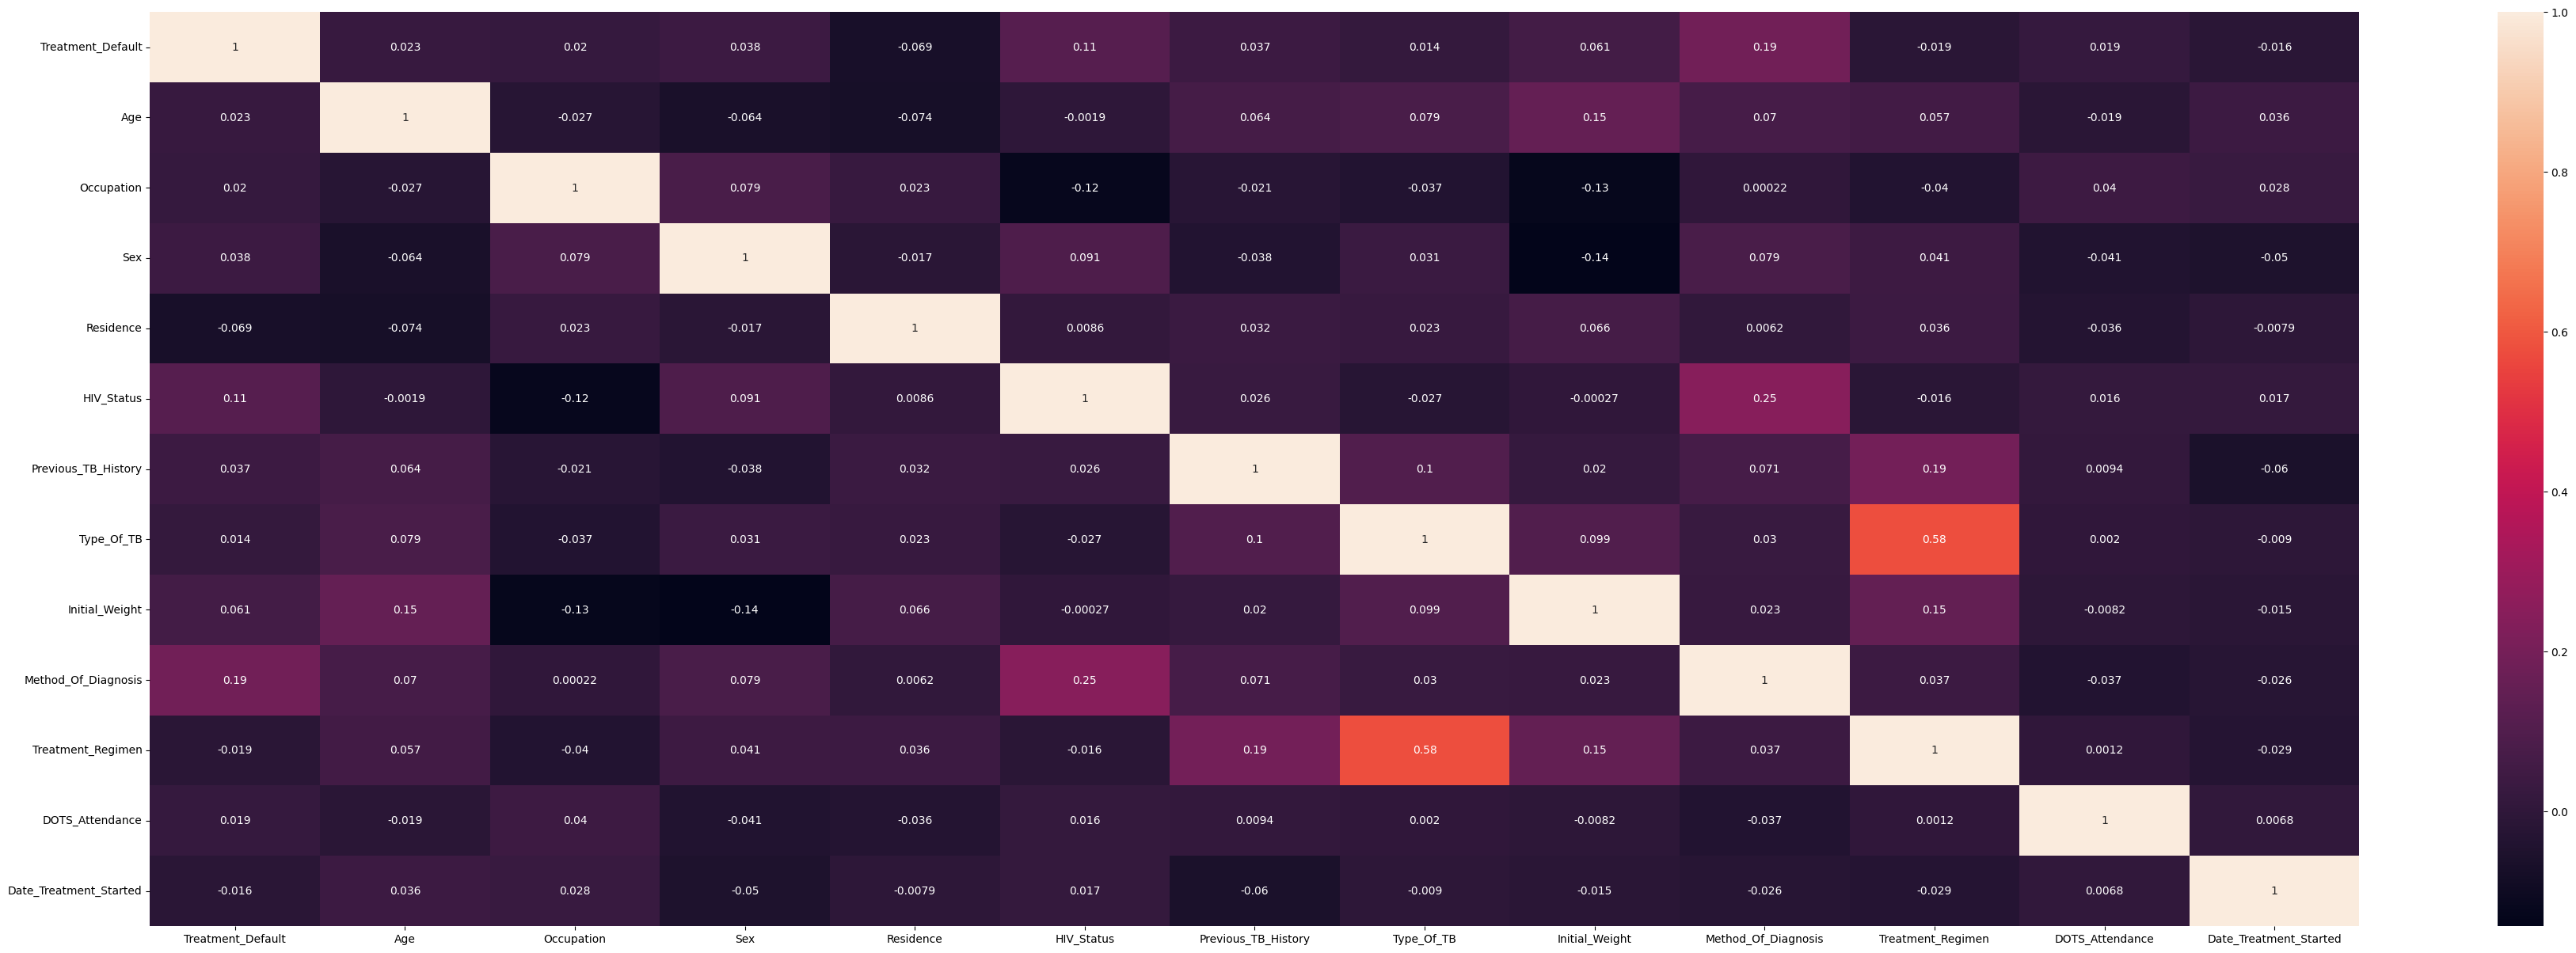

In [ ]:
# Plot a correlation chart of df features

df_encoded_corr = df_copy.corr()

plt.figure(figsize = (45, 15))

sns.heatmap(df_encoded_corr, annot = True)

plt.show()

In [ ]:
# List out the correlation of each feature with Treatment_Default

df_corr_list = df_encoded_corr['Treatment_Default'].sort_values(ascending = True ).reset_index()

df_corr_list

,index,Treatment_Default
0,Residence,-0.068805
1,Treatment_Regimen,-0.018583
2,Date_Treatment_Started,-0.016178
3,Type_Of_TB,0.014393
4,DOTS_Attendance,0.018583
5,Occupation,0.019692
6,Age,0.023333
7,Previous_TB_History,0.037447
8,Sex,0.038414
9,Initial_Weight,0.061234


 From the `Correlation Chart of df`, it is evident that individually, none of the features linearly correlate highly with the target `Treatment_Default`

###Descriptive statistics, univariate analysis of each variables, Bivariate analysis between two variables!


###1.) Treatment Default.

In [ ]:
df['Treatment_Default'].value_counts(normalize=True)

,proportion
Treatment_Default,
0,0.769585
1,0.230415


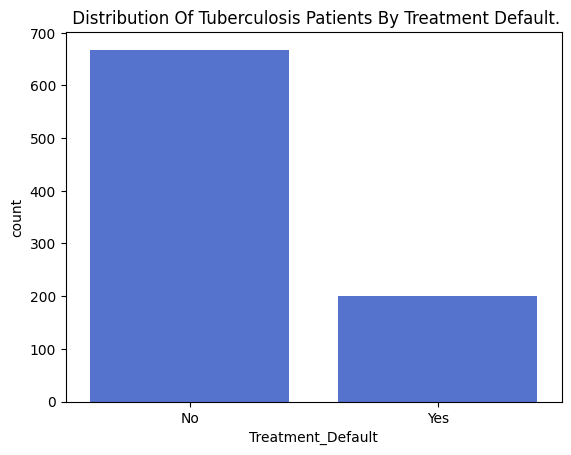

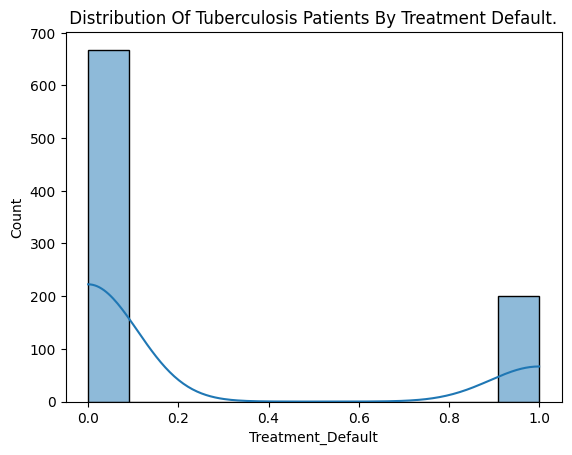

In [ ]:
# Univariate analysis of Treatment_Default!

sns.countplot(data = df, x = 'Treatment_Default', color = 'RoyalBlue')

plt.xticks(ticks = [0,1], labels = ['No', 'Yes'])

plt.title(' Distribution Of Tuberculosis Patients By Treatment Default.')
plt.show()

# Univariate analysis of Treatment Default!

sns.histplot(data = df, x = 'Treatment_Default', kde=True)

plt.title(' Distribution Of Tuberculosis Patients By Treatment Default. ')
plt.show()

**Insights**
- The chart clearly shows that treatment default among tuberculosis patients is not strong, with over `668 individuals` not having treatment default compared to just above `200` who defaulted.
- This suggests a healthy treatment plan followed through among tuberculosis patient, though the treatment default group despite being smaller warrants attention to discover any underlying causes and prevent future occcurences of treatment default.

###2.) Age.

In [ ]:
df['Age'].value_counts()

,count
Age,
45,57
19,50
40,50
35,44
30,40
...,...
86,1
73,1
66,1


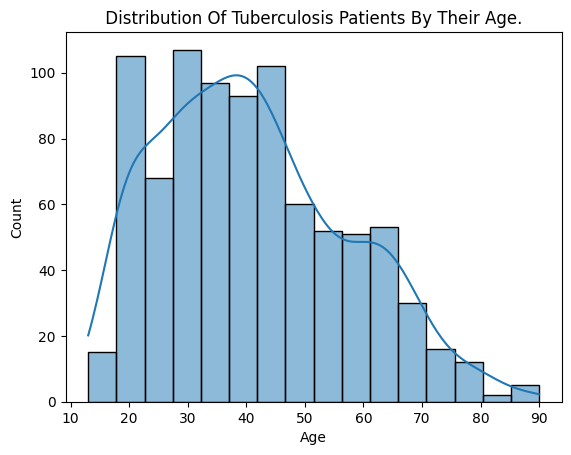

In [ ]:
# Univariate analysis of Age!

sns.histplot(data = df, x = 'Age', kde=True)

plt.title(' Distribution Of Tuberculosis Patients By Their Age. ')
plt.show()

**Insight**

- Most tuberculosis cases are found among adults aged 18 to 45, with the highest numbers of people in their 20s and 30s.
This shows that the disease mainly affects students and working-age adults, possibly due to school and work-related exposure
or frequent movement and interactions.

- After age 45, the number of cases gradually decreases, with much fewer tuberculosis cases seen in the elderly ones,
even though the data extends up to age 80 and above.
There is a small increase again between ages 55 and 65, suggesting older adults may also be at some risk.

- Very few cases are seen in children below age 15, indicating that children are less affected.

#####BIVARIATE ANALYSIS (TREATMENT DEFAULT OF TUBERCULOSIS PATIENTS BY AGE)

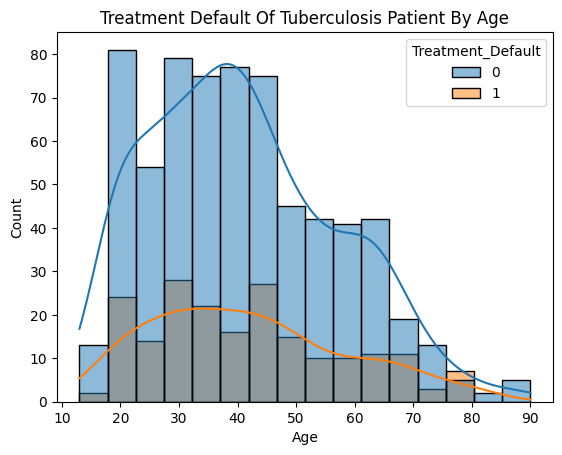

In [ ]:
sns.histplot(data = df, x = 'Age', hue ='Treatment_Default', kde=True)

plt.title('Treatment Default Of Tuberculosis Patient By Age')
plt.show()

In [ ]:
Age_group = pd.cut(df['Age'], bins = [15, 20, 30, 40, 50, 60, 70, 80, 90 ], labels = ['11 - 20', '21 - 30', '31 - 40', '41 - 50', '51 - 60', '61 - 70', '71 - 80', '81 - 90'])

Age_group

,Age
0,51 - 60
1,11 - 20
2,51 - 60
3,11 - 20
4,41 - 50
...,...
863,21 - 30
864,21 - 30
865,41 - 50
866,31 - 40


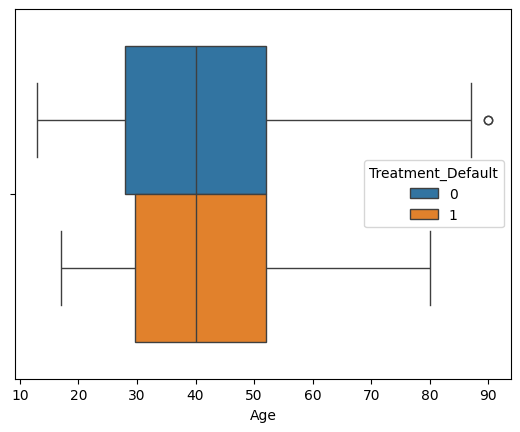

In [ ]:
# Check for outliers

sns.boxplot(data = df, x = 'Age', hue ='Treatment_Default')

plt.show()

###3.) Previous TB History.

In [ ]:
Previous_TB_History = df['Previous_TB_History'].value_counts()

Previous_TB_History.reset_index()

,Previous_TB_History,count
0,0,800
1,1,56
2,2,12


####UNIVARIATE ANALYSIS OF PREVIOUS TB HISTORY.

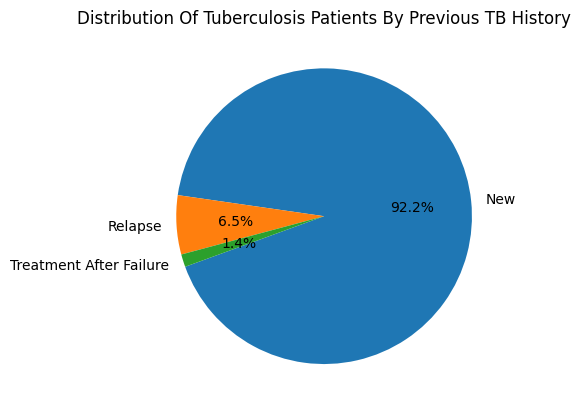

In [ ]:
# Distribution of Employee

labels = ['New', 'Relapse', 'Treatment After Failure']

plt.pie(Previous_TB_History, labels = labels, autopct='%1.1f%%', startangle=2000)
plt.title('Distribution Of Tuberculosis Patients By Previous TB History')
plt.show()

# Univariate analysis of Age!

sns.histplot(data = df, x = 'Age', kde=True)

plt.title(' Distribution Of Tuberculosis Patients By Their Age. ')
plt.show()